# Voyage AI — Bild-Embedding & Ähnlichkeitsvergleich

Demo: Marken-Logos als Bilder mit **voyage-multimodal-3** vektorisieren und per Cosine Similarity vergleichen.

| Schritt | Was passiert |
|---------|-------------|
| 1 | Setup & VoyageAI-Client initialisieren |
| 2 | Bilder laden & anzeigen |
| 3 | Bilder vektorisieren (multimodal embedding) |
| 4 | Ähnlichkeitsmatrix berechnen |
| 5 | Paarvergleich im Detail |

## 1 — Setup & Imports

In [1]:
import sys, math
from pathlib import Path

# --- acai auf den Python-Pfad legen ---
_lib = Path.cwd()
while _lib.name != "acai-powertools" and _lib != _lib.parent:
    _lib = _lib.parent
_lib = _lib / "lib"
if str(_lib) not in sys.path:
    sys.path.insert(0, str(_lib))

# --- VoyageAI API Key aus marken-bot/.env laden ---
from dotenv import load_dotenv
import os

_project_root = _lib.parent.parent  # → 2026 LexChat
load_dotenv(dotenv_path=_project_root / "marken-bot" / ".env")

VOYAGE_API_KEY = os.environ["VOYAGEAI_API_KEY"]

# --- VoyageAI Multimodal Client ---
import voyageai
import PIL.Image
from IPython.display import display

vo = voyageai.Client(api_key=VOYAGE_API_KEY)
print("VoyageAI multimodal client ready ✔")

VoyageAI multimodal client ready ✔


c:\Users\micha\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 — Bilder laden & anzeigen

Drei Marken-Logos aus dem `_example/`-Ordner laden und inline darstellen.


────────────────────────────────────────
  WMF  (164×176 px, mode=RGBA)
────────────────────────────────────────


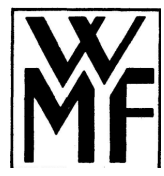


────────────────────────────────────────
  WMM  (184×124 px, mode=RGBA)
────────────────────────────────────────


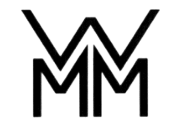


────────────────────────────────────────
  RWE  (417×121 px, mode=P)
────────────────────────────────────────


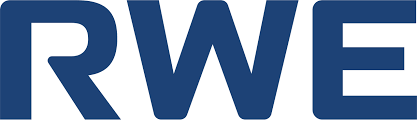

In [2]:
# --- Bilder laden ---
_example_dir = Path(".").resolve()

images = {
    "WMF": PIL.Image.open(_example_dir / "WMF.png"),
    "WMM": PIL.Image.open(_example_dir / "WMM.png"),
    "RWE": PIL.Image.open(_example_dir / "rwe.png"),
}

for name, img in images.items():
    print(f"\n{'─'*40}")
    print(f"  {name}  ({img.size[0]}×{img.size[1]} px, mode={img.mode})")
    print(f"{'─'*40}")
    display(img)

## 3 — Bilder vektorisieren (voyage-multimodal-3)

Jedes Bild wird einzeln als Input an `multimodal_embed` übergeben.  
Pro Input: eine Liste mit einem PIL-Image-Objekt.

In [3]:
names = list(images.keys())
inputs = [[img] for img in images.values()]

result = vo.multimodal_embed(
    inputs=inputs,
    model="voyage-multimodal-3",
    input_type="document",
)

vectors = {name: vec for name, vec in zip(names, result.embeddings)}

dim = len(result.embeddings[0])
print(f"{len(result.embeddings)} Embeddings erzeugt (Dimension: {dim})")
print(f"Total tokens: {result.total_tokens}  |  Image pixels: {result.image_pixels}\n")
for name, vec in vectors.items():
    print(f"  • {name:6s}  →  [{vec[0]:+.4f}, {vec[1]:+.4f}, {vec[2]:+.4f}, …]")

3 Embeddings erzeugt (Dimension: 1024)
Total tokens: 268  |  Image pixels: 150457

  • WMF     →  [+0.0422, +0.0023, -0.0010, …]
  • WMM     →  [+0.0518, +0.0103, -0.0007, …]
  • RWE     →  [+0.0269, +0.0083, +0.0265, …]


## 4 — Ähnlichkeitsmatrix (Cosine Similarity & Euklidische Distanz)

Cosine Similarity misst die Richtungsähnlichkeit der Vektoren (1 = identisch, 0 = orthogonal).  
Euklidische Distanz misst den absoluten Abstand (0 = identisch, grösser = weiter entfernt).

In [4]:
def cosine_sim(a: list[float], b: list[float]) -> float:
    """Cosine similarity (= dot product for normalised vectors)."""
    return sum(x * y for x, y in zip(a, b))

def euclidean_dist(a: list[float], b: list[float]) -> float:
    """Euclidean distance between two vectors."""
    return math.sqrt(sum((x - y) ** 2 for x, y in zip(a, b)))

# --- Cosine Similarity Matrix ---
n = len(names)
print("=== Cosine Similarity ===")
header = "          " + "  ".join(f"{t:>8s}" for t in names)
print(header)
print("-" * len(header))
for i in range(n):
    cells = "  ".join(f"{cosine_sim(vectors[names[i]], vectors[names[j]]):8.4f}" for j in range(n))
    print(f"{names[i]:10s}{cells}")

# --- Euclidean Distance Matrix ---
print("\n=== Euklidische Distanz ===")
print(header)
print("-" * len(header))
for i in range(n):
    cells = "  ".join(f"{euclidean_dist(vectors[names[i]], vectors[names[j]]):8.4f}" for j in range(n))
    print(f"{names[i]:10s}{cells}")

=== Cosine Similarity ===
               WMF       WMM       RWE
--------------------------------------
WMF         1.0056    0.8044    0.5569
WMM         0.8044    0.9992    0.5501
RWE         0.5569    0.5501    1.0023

=== Euklidische Distanz ===
               WMF       WMM       RWE
--------------------------------------
WMF         0.0000    0.6292    0.9456
WMM         0.6292    0.0000    0.9494
RWE         0.9456    0.9494    0.0000


## 5 — Paarvergleich im Detail

Alle drei Bildpaare mit Cosine Similarity, Euklidischer Distanz und qualitativer Bewertung.

In [5]:
pairs = [
    ("WMF", "WMM"),
    ("WMF", "RWE"),
    ("WMM", "RWE"),
]

print(f"{'Paar':<20s}  {'Cos Sim':>8s}  {'Eukl Dist':>10s}  Bewertung")
print("─" * 65)
for a, b in pairs:
    sim = cosine_sim(vectors[a], vectors[b])
    dist = euclidean_dist(vectors[a], vectors[b])
    if sim >= 0.85:
        label = "⚠️  SEHR ÄHNLICH"
    elif sim >= 0.60:
        label = "🔶 ähnlich"
    elif sim >= 0.40:
        label = "🔹 moderat"
    else:
        label = "✅ verschieden"
    bar = "█" * int(sim * 40)
    print(f"{a + '  ↔  ' + b:<20s}  {sim:8.4f}  {dist:10.4f}  {label}  {bar}")

Paar                   Cos Sim   Eukl Dist  Bewertung
─────────────────────────────────────────────────────────────────
WMF  ↔  WMM             0.8044      0.6292  🔶 ähnlich  ████████████████████████████████
WMF  ↔  RWE             0.5569      0.9456  🔹 moderat  ██████████████████████
WMM  ↔  RWE             0.5501      0.9494  🔹 moderat  ██████████████████████
